In [30]:
import numpy as np 
from matplotlib import pyplot as plt 
import os 
from qcat import calculate_ssim
from edt import edt 
import ctypes

    
def calculate_psnr(src_data, dec_data):
    data_range = np.max(src_data) - np.min(src_data)
    diff = src_data - dec_data
    max_diff = np.max(abs(diff))
    # print("abs err={:.8G}".format(max_diff))
    mse = np.mean(diff ** 2)
    psnr = 20 * np.log10(data_range) - 10 * np.log10(mse)
    return psnr 

In [31]:
import numpy as np 
from matplotlib import pyplot as plt 
import os 
from qcat import calculate_ssim
from edt import edt 
import ctypes

    
def calculate_psnr(src_data, dec_data):
    data_range = np.max(src_data) - np.min(src_data)
    diff = src_data - dec_data
    max_diff = np.max(abs(diff))
    # print("abs err={:.8G}".format(max_diff))
    mse = np.mean(diff ** 2)
    psnr = 20 * np.log10(data_range) - 10 * np.log10(mse)
    return psnr 

In [32]:
def show(locations, results):
    odata = results['odata']
    ddata = results['ddata']
    post = results['post']
    orig_error = odata - ddata 
    post_error = odata - post 
    predicted_error = post - ddata  
    figs, axs = plt.subplots(2, 3, figsize=(9, 6)) 
    d_max = np.max(odata[locations])/2
    d_min = np.min(odata[locations])/2
    e_max = np.max(orig_error[locations]) 
    e_min = np.min(orig_error[locations]) 
    axs[0,0].imshow(odata[locations], cmap='coolwarm', vmin=d_min, vmax=d_max)
    axs[0,0].set_title('Original Data')
    axs[0,1].imshow(ddata[locations], cmap='coolwarm', vmin=d_min, vmax=d_max)
    axs[0,1].set_title(f'Quantized Data\n psnr={results["orig_psnr"]:.2f}, ssim={results["orig_ssim"]:.4f}')
    axs[0,2].imshow(post[locations], cmap='coolwarm', vmin=d_min, vmax=d_max)
    axs[0,2].set_title(f'Compensated Data\n psnr={results["post_psnr"]:.2f}, ssim={results["post_ssim"]:.4f}')
    axs[1,0].imshow(orig_error[locations], cmap='coolwarm', vmin=e_min, vmax=e_max)
    axs[1,0].set_title('Original Error')
    axs[1,1].imshow(post_error[locations], cmap='coolwarm', vmin=e_min, vmax=e_max)
    axs[1,1].set_title('Compensated Error')
    axs[1,2].imshow(predicted_error[locations], cmap='coolwarm', vmin=e_min, vmax=e_max)
    axs[1,2].set_title('Predicted Error')
    plt.tight_layout()
    plt.show()

In [33]:
def get_data(orig_path, ddata_path, post_path, shape, rel_eb, user_rbf=0 ):
    data_path = orig_path
    odata = np.fromfile(data_path, dtype=np.float32).reshape(shape)
    ddata = np.fromfile(ddata_path, dtype=np.float32).reshape(shape)
    cdata = np.fromfile(post_path, dtype=np.float32).reshape(shape)
    # ddata, cdata, output = edt(odata, rel_eb, user_rbf=user_rbf)
    orig_psnr = calculate_psnr(odata, ddata)
    post_psnr = calculate_psnr(odata, cdata)
    orig_ssim = calculate_ssim(odata, ddata)
    post_ssim = calculate_ssim(odata, cdata)
    results = {
        'odata': odata,
        'ddata': ddata,
        'post': cdata,
        'orig_psnr': orig_psnr,
        'post_psnr': post_psnr,
        'orig_ssim': orig_ssim,
        'post_ssim': post_ssim
    }
    return results

dims: 256, 384, 384
dims: 256, 384, 384


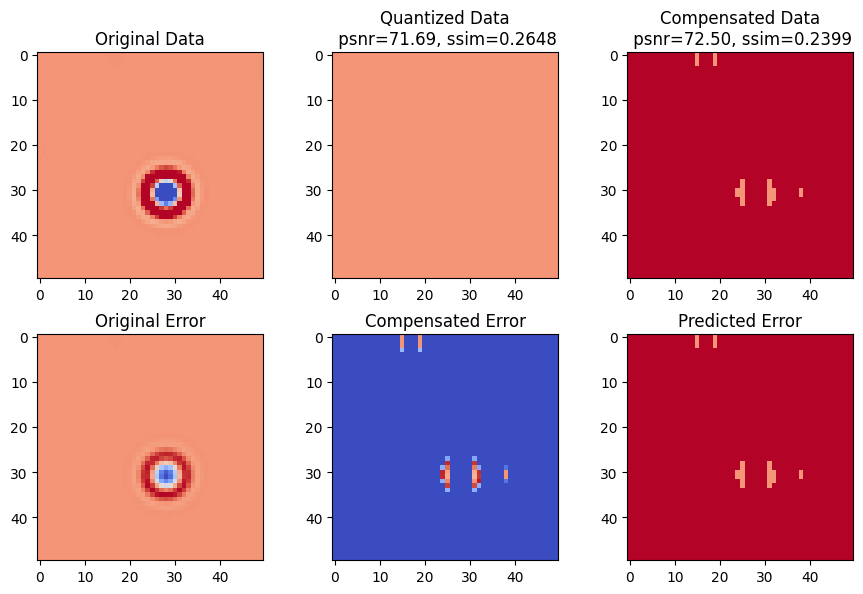

In [75]:
data_path = '/scratch/pji228/useful/hpez_qoi/data/miranda_256x384x384/viscocity.f32' 
ddata_path = '../build/quantized.dat'
post_path = '../build/postdata.dir3.f32' 
results = get_data(data_path, ddata_path, post_path, (256, 384, 384), rel_eb=0.001)        
locations = (81, slice(200,250), slice(200,250)) 

show(locations, results)

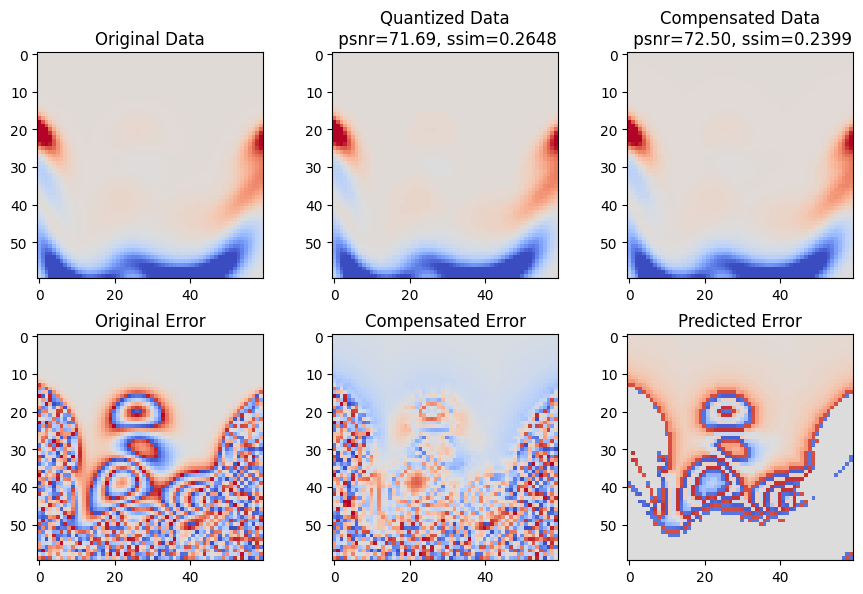

In [76]:
locations = (slice(90,150), slice(100,160), 193 ) 
# locations = ( slice(None), 100,  slice(None) ) 
# # locations = (110, slice(100,200), slice(100,200)) 


show(locations, results)

In [36]:
locations = (110, slice(100,200), slice(None) ) 


In [37]:
results['odata'][96].tofile('/tmp/odata96.f32')

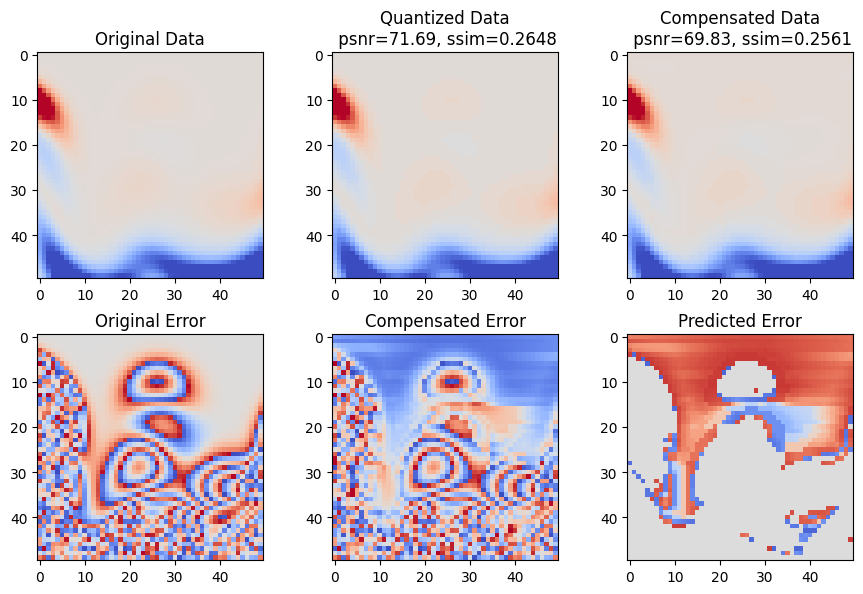

In [62]:
locations = (slice(100,150), slice(100,150), 193 ) 
show(locations, results)

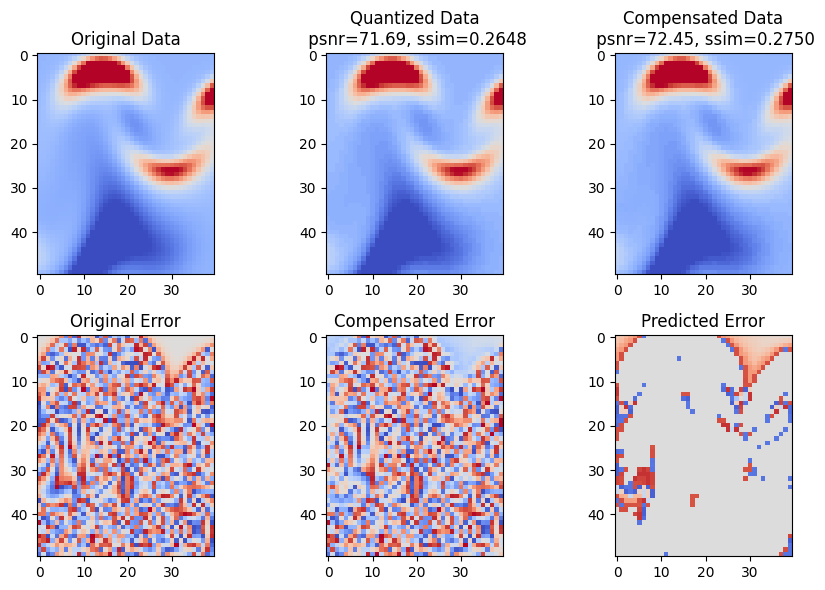

In [39]:
locations = (slice(100,150), 20, slice(193-20, 193+20) ) 
show(locations, results)

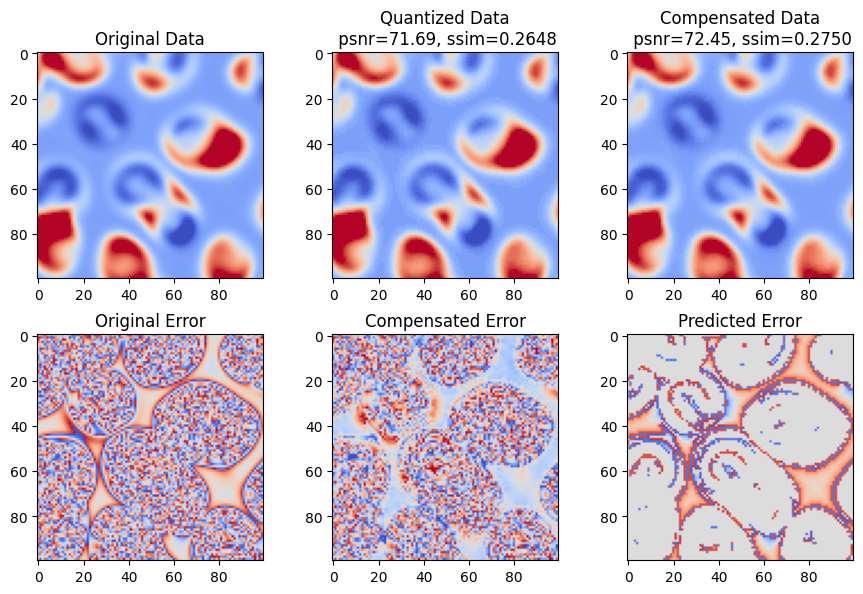

In [40]:
locations = (120, slice(200,300),slice(200,300)) 
show(locations, results)

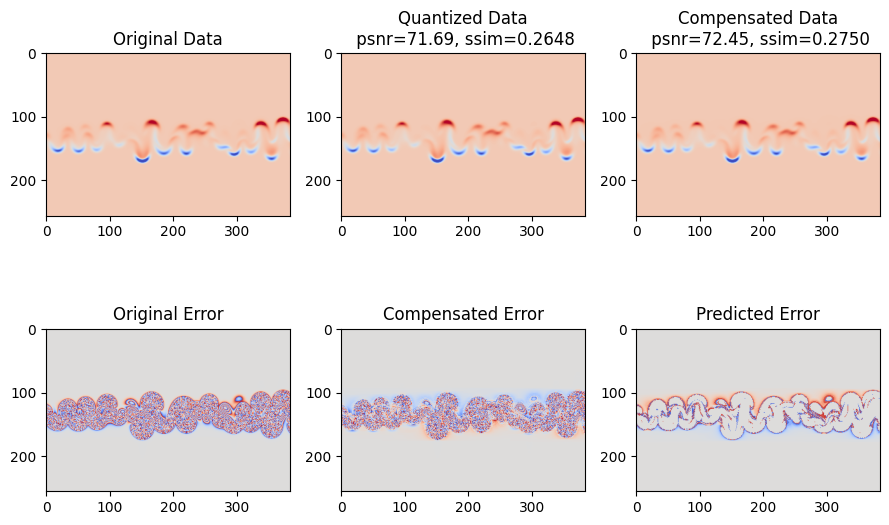

In [41]:
locations = (slice(None), 193, slice(None)) 
show(locations, results)

In [42]:
avg_ssim, ssim_map, map_shape  = calculate_ssim(results['odata'], results['ddata'], return_map= True) 
avg_ssim_post, ssim_map_post, map_shape_post  = calculate_ssim(results['odata'], results['post'], return_map= True) 

In [43]:
print(f"avg_ssim: {avg_ssim:.4f}, avg_ssim_post: {avg_ssim_post:.4f}")

avg_ssim: 0.2648, avg_ssim_post: 0.2750


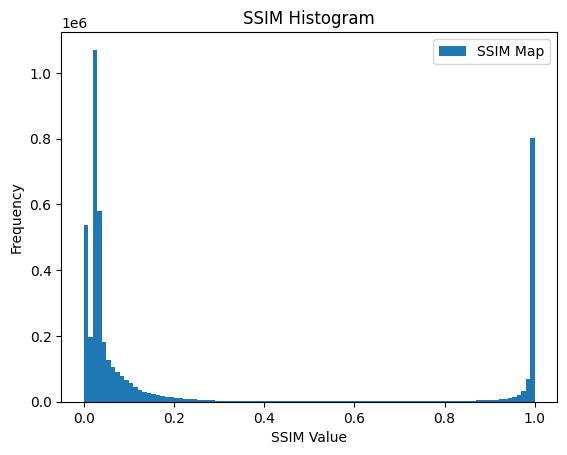

In [44]:
plt.hist(ssim_map.flatten(), bins=100, range=(0, 1), label='SSIM Map')
plt.xlabel('SSIM Value')
plt.ylabel('Frequency')
plt.title('SSIM Histogram')
plt.legend()

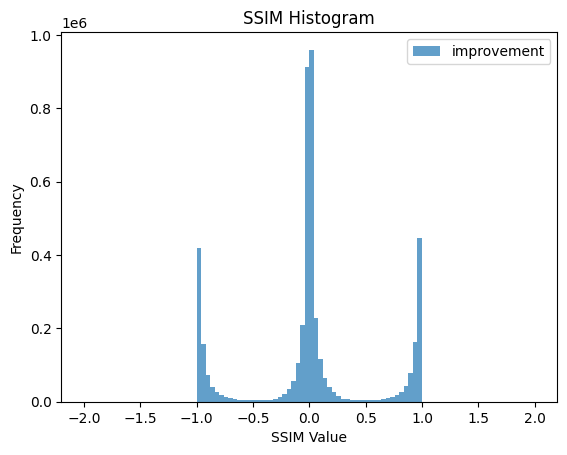

In [45]:
# plt.hist(ssim_map.flatten(), bins=100, range=(0, 1), label='Orig SSIM Map',color='k')
plt.hist(ssim_map_post.flatten() - ssim_map.flatten(), bins=100, range=(-2, 2), label='improvement' , alpha=0.7)
plt.xlabel('SSIM Value')
plt.ylabel('Frequency')
plt.title('SSIM Histogram')
plt.legend()

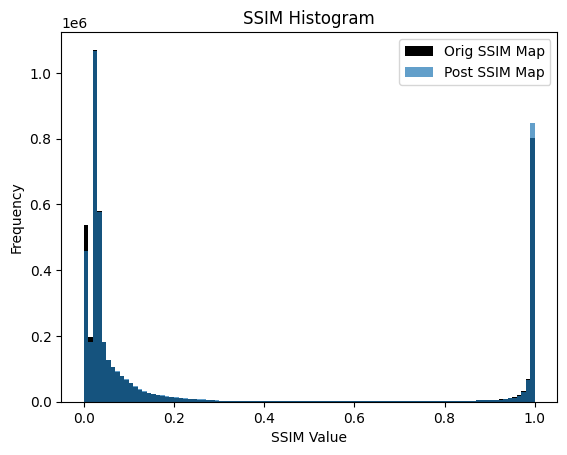

In [46]:
plt.hist(ssim_map.flatten(), bins=100, range=(0, 1), label='Orig SSIM Map',color='k')
plt.hist(ssim_map_post.flatten(), bins=100, range=(0, 1), label='Post SSIM Map', alpha=0.7)
plt.xlabel('SSIM Value')
plt.ylabel('Frequency')
plt.title('SSIM Histogram')
plt.legend()

In [47]:
print(f"map_shape_post: {map_shape_post}")

map_shape_post: (125, 189, 189)


In [48]:
locations = (slice(100,150), slice(100,150), 193 ) 

max ssim window: 1.0000, min: -0.8275


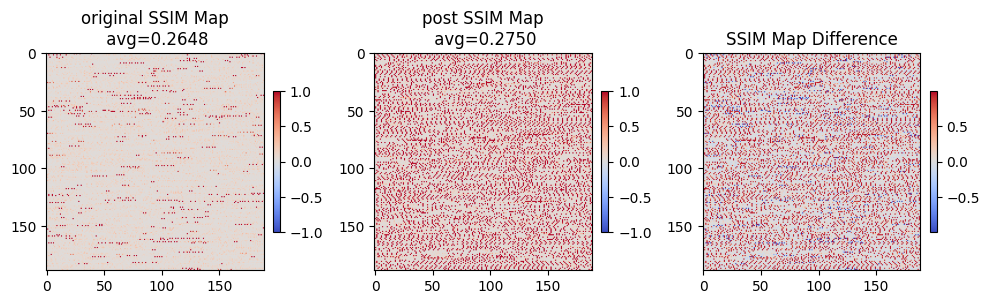

In [49]:
locations = (slice(None), 60 , slice(None)) 
locations = (60, slice(None), slice(None)) 
fig, ax = plt.subplots(1,3, figsize=(10, 5))
v_max = 1
v_min = -1.0
print(f"max ssim window: {np.max(ssim_map):.4f}, min: {np.min(ssim_map):.4f}")
ax[0].imshow(ssim_map[locations], cmap='coolwarm', vmin=v_min, vmax=v_max)
ax[0].set_title('original SSIM Map\n avg={:.4f}'.format(avg_ssim))
ax[1].imshow(ssim_map_post[locations], cmap='coolwarm', vmin=v_min, vmax=v_max)
ax[1].set_title('post SSIM Map\n avg={:.4f}'.format(avg_ssim_post))
ax[2].imshow(ssim_map_post[locations] - ssim_map[locations], cmap='coolwarm')
ax[2].set_title('SSIM Map Difference')
for i in range(3):
    plt.colorbar(ax[i].images[0], ax=ax[i], fraction=0.03, pad=0.04)
plt.tight_layout()
plt.show()

In [50]:
# how many windows are improved?[locations]
locations= (slice(None), slice(None), slice(None))
improved = np.sum(ssim_map_post[locations] > ssim_map[locations])
print(f"Number of improved windows: {improved} out of {np.prod(ssim_map_post[locations].shape)}")
print(f"Improvement ratio: {improved/np.prod(ssim_map_post[locations].shape):.4f}")
# what is the increase rage of these windows? 
increase = ssim_map_post[locations] - ssim_map[locations]
increase = increase[ssim_map_post[locations] > ssim_map[locations]]
print(f"Average increase in SSIM for improved windows: {np.mean(increase):.4f}")
print(f"Max increase in SSIM for improved windows: {np.max(increase):.4f}")
print(f"Min increase in SSIM for improved windows: {np.min(increase):.9f}")

Number of improved windows: 2303827 out of 4465125
Improvement ratio: 0.5160
Average increase in SSIM for improved windows: 0.3647
Max increase in SSIM for improved windows: 1.7556
Min increase in SSIM for improved windows: 0.000000003


In [51]:
# it uses sliding window of 7x7x7 and the stride of 2 2 2,
# locate the window with the best SSIM
best_window = np.unravel_index(np.argmax(ssim_map), ssim_map.shape)
best_window = np.unravel_index(np.argmax(increase), ssim_map.shape)

print(f"Best window location: {best_window}")
# get the location of this window in the original data
best_window_location = (slice(best_window[0] * 2, best_window[0] * 2 + 7),
                        slice(best_window[1] * 2, best_window[1] * 2 + 7), 
                        slice(best_window[2] * 2, best_window[2] * 2 + 7))
windows_psnr = calculate_psnr(results['odata'][best_window_location], results['ddata'][best_window_location])
win_ssim = calculate_ssim(results['odata'][best_window_location], results['ddata'][best_window_location])
print(f"PSNR for the best window: {windows_psnr:.4f}")
print(f"SSIM for the best window: {win_ssim:.4f}") 

Best window location: (63, 131, 143)
PSNR for the best window: 36.9099
SSIM for the best window: 0.9980
dims: 7, 7, 7


In [52]:
best_window_location

(slice(126, 133, None), slice(262, 269, None), slice(286, 293, None))

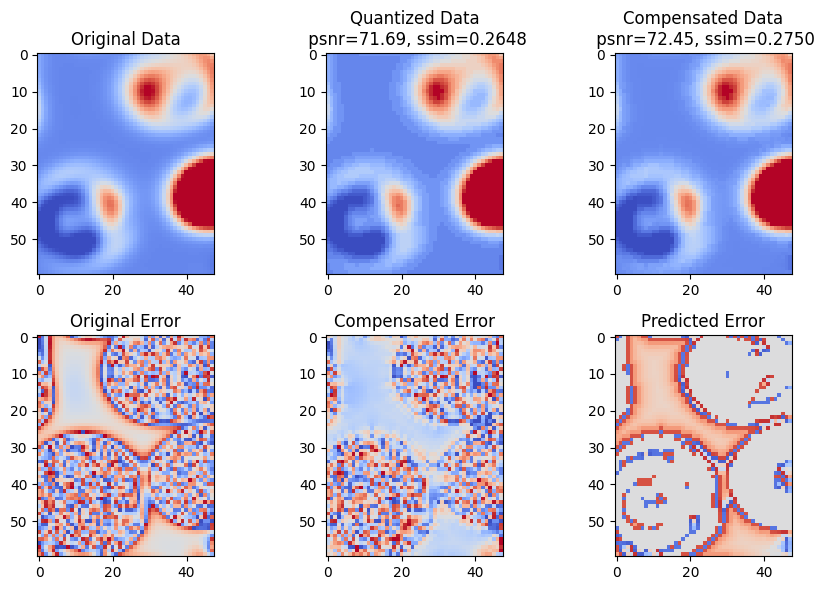

In [53]:
offset = 20 
locations = (119, slice(64-offset, 64+2*offset), slice(356-offset, 356+2*offset)) 

show(locations, results)


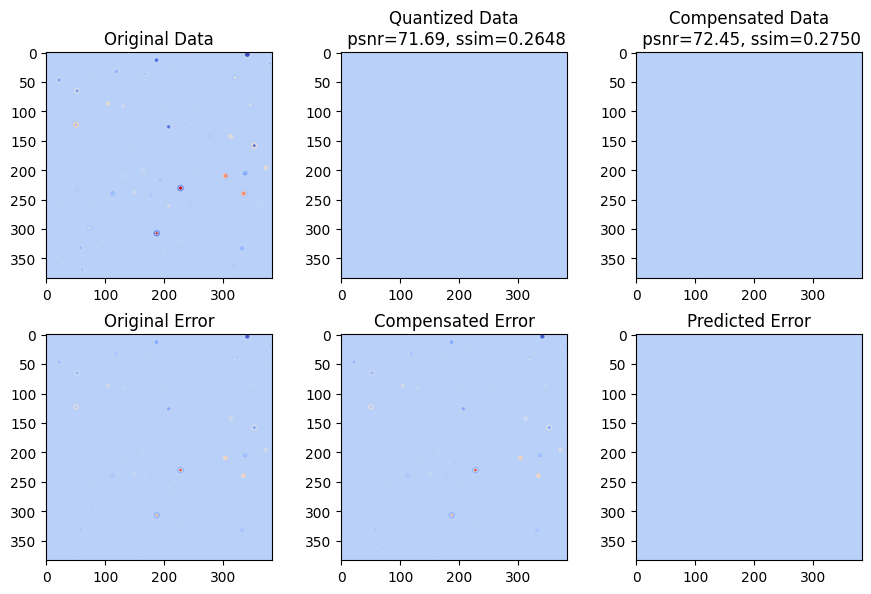

In [54]:
locations = (64, slice(None), slice(None)) 
show(locations, results)

In [55]:
slice_odata = results['odata'][locations] 
slice_ddata = results['ddata'][locations] 
slice_post = results['post'][locations]
orig_error = slice_odata - slice_ddata
post_error = slice_odata - slice_post 
print(f'max orig error {orig_error.max():.8f}, min {orig_error.min():.8f}')
print(f'max post error {post_error.max():.8f}, min {post_error.min():.8f}') 

max orig error 0.00000051, min -0.00000032
max post error 0.00000051, min -0.00000032


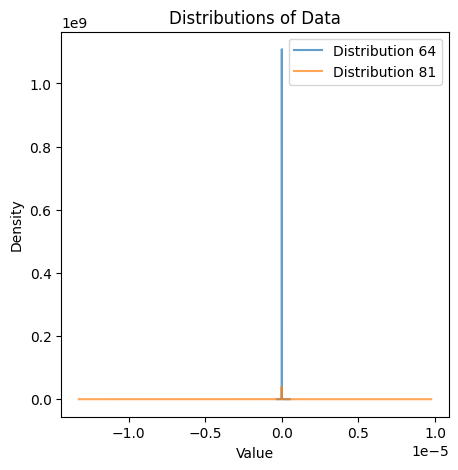

In [56]:
distributions = [] 
distributions.append(np.histogram(results['odata'][64].flatten(), bins=1000, density=True))
distributions.append(np.histogram(results['odata'][81].flatten(), bins=1000, density=True))
# plot the distributions on the same figure with different colors 
slice_index = [64, 81]
fig, ax = plt.subplots(figsize=(5,5))
for i, (hist, bin_edges) in enumerate(distributions):
    ax.plot(bin_edges[:-1], hist, label=f'Distribution {slice_index[i]}', alpha=0.7)
ax.set_title('Distributions of Data')
ax.set_xlabel('Value')
ax.set_ylabel('Density')
ax.legend()

In [57]:
abs_eb = np.max(np.abs(results['odata']- results['ddata']))
print(f'orig max = {np.max(results["odata"])}, orig min = {np.min(results["odata"])}')
print(f'abs error bound={abs_eb:.8G}')

orig max = 0.9447011947631836, orig min = -1.6766325235366821
abs error bound=0.0026213333


In [58]:
data_path = '/scratch/pji228/useful/hpez_qoi/data/miranda_256x384x384/viscocity.f32' 
log_tempreature = np.log10(np.fromfile(data_path, dtype=np.float32).reshape((256, 384, 384)))
log_tempreature.tofile('/tmp/log_tempreature.f32')
results = get_data('/tmp/log_tempreature.f32', (256, 384, 384), 0.0005)
locations = (81, slice(200,300), slice(200,300)) 
show(locations, results)

/tmp/ipykernel_921899/1701006686.py:2: RuntimeWarning: invalid value encountered in log10
  log_tempreature = np.log10(np.fromfile(data_path, dtype=np.float32).reshape((256, 384, 384)))


TypeError: get_data() missing 2 required positional arguments: 'shape' and 'rel_eb'

In [ ]:
data_path = '/scratch/pji228/useful/hpez_qoi/data/miranda_256x384x384/density.f32' 

results = get_data(data_path, (256, 384, 384), 0.0005)
locations = (81, slice(200,300), slice(200,300)) 
show(locations, results)


In [ ]:
file_folder = '/scratch/pji228/useful/hpez_qoi/data/miranda_256x384x384'
file_ext ='f32'
file_list = [os.path.join(file_folder, f) for f in os.listdir(file_folder) if f.endswith(file_ext)]
file_histories = {}
for f in file_list:
    data = np.fromfile(f, dtype=np.float32)
    hist, bin_edges = np.histogram(data, bins=1000)
    file_histories[os.path.basename(f)] = {'hist': hist, 'bin_edges': bin_edges}

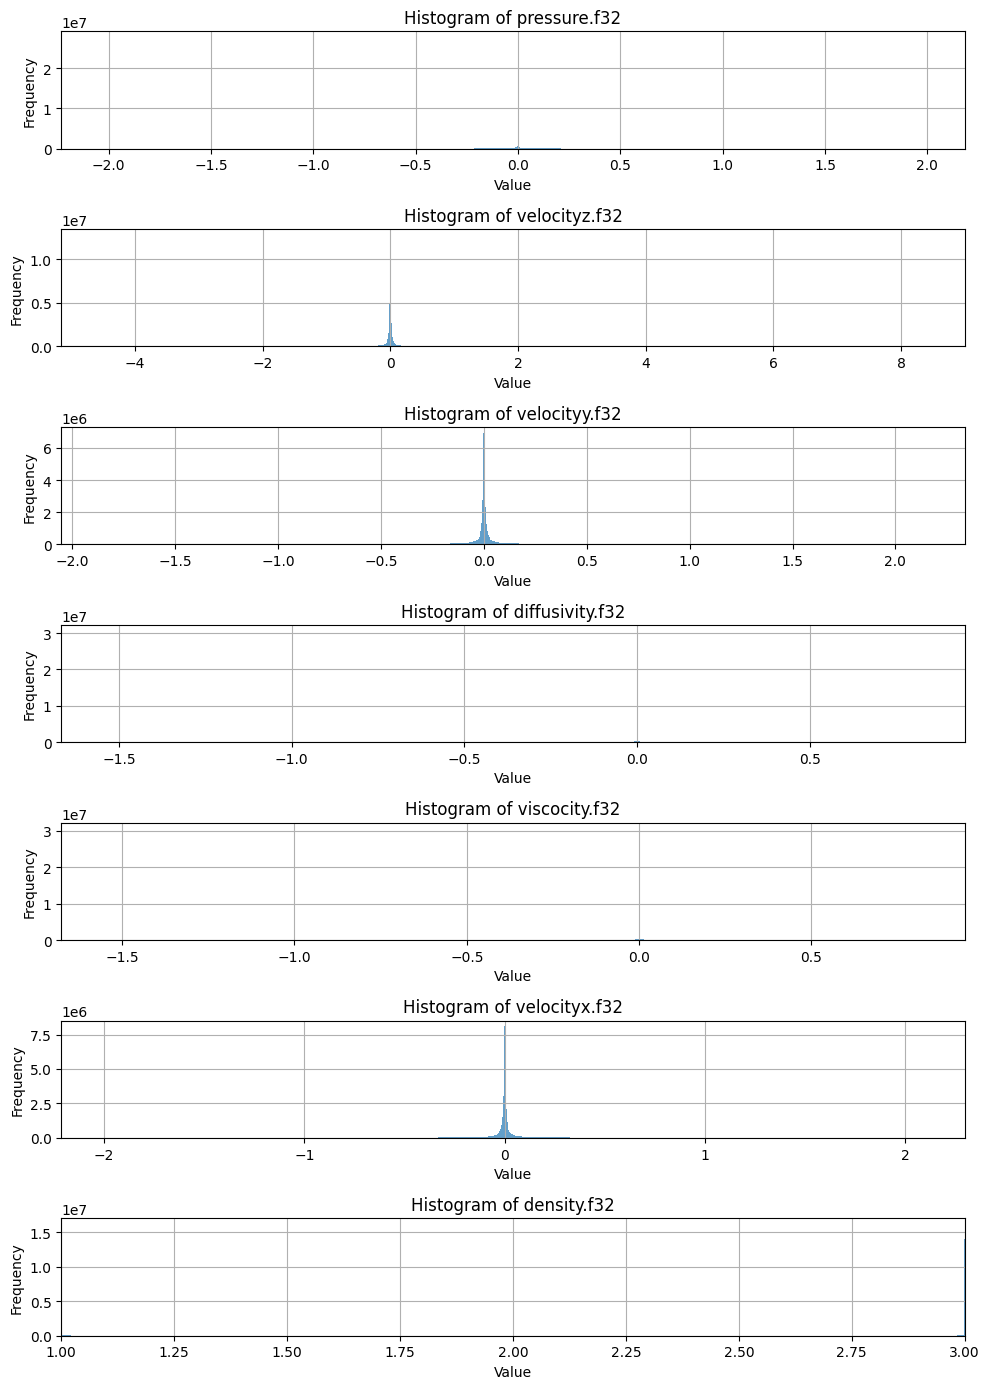

In [ ]:
figs, axs = plt.subplots(len(file_histories), 1, figsize=(10, 2 * len(file_histories)))
for i, (filename, hist_data) in enumerate(file_histories.items()):
    axs[i].bar(hist_data['bin_edges'][:-1], hist_data['hist'], width=np.diff(hist_data['bin_edges']), align='edge', alpha=0.7)
    axs[i].set_title(f'Histogram of {filename}')
    axs[i].set_xlabel('Value')
    axs[i].set_ylabel('Frequency')
    axs[i].set_xlim(hist_data['bin_edges'][0], hist_data['bin_edges'][-1])
    axs[i].grid(True)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist, squareform
import time

def cluster_analysis(data_values, distance_transform, method='kmeans', n_clusters=2):
    """
    Cluster points based on their values and distance transform
    
    Args:
        data_values: 1D array of data values
        distance_transform: 1D array of distance transform values
        method: 'kmeans', 'gmm', or 'dbscan'
        n_clusters: number of clusters (for kmeans and gmm)
    
    Returns:
        cluster_labels: array of cluster assignments
        clustering_time: time taken for clustering
    """
    # Prepare feature matrix
    features = np.column_stack([data_values.flatten(), distance_transform.flatten()])
    
    # Standardize features for better clustering
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features)
    
    start_time = time.time()
    
    if method == 'kmeans':
        clusterer = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        labels = clusterer.fit_predict(features_scaled)
    elif method == 'gmm':
        clusterer = GaussianMixture(n_components=n_clusters, random_state=42)
        labels = clusterer.fit_predict(features_scaled)
    elif method == 'dbscan':
        # For DBSCAN, we need to estimate eps parameter
        eps = np.percentile(pdist(features_scaled), 10)  # Use 10th percentile as eps
        clusterer = DBSCAN(eps=eps, min_samples=10)
        labels = clusterer.fit_predict(features_scaled)
    
    clustering_time = time.time() - start_time
    
    return labels, clustering_time, features_scaled

def visualize_clusters(features_scaled, labels, method_name, data_shape):
    """Visualize clustering results"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # 2D scatter plot of features
    unique_labels = np.unique(labels)
    colors = plt.cm.Set1(np.linspace(0, 1, len(unique_labels)))
    
    for label, color in zip(unique_labels, colors):
        mask = labels == label
        if label == -1:  # Noise points for DBSCAN
            ax1.scatter(features_scaled[mask, 0], features_scaled[mask, 1], 
                       c='black', marker='x', s=20, alpha=0.5, label='Noise')
        else:
            ax1.scatter(features_scaled[mask, 0], features_scaled[mask, 1], 
                       c=[color], s=20, alpha=0.7, label=f'Cluster {label}')
    
    ax1.set_xlabel('Standardized Data Values')
    ax1.set_ylabel('Standardized Distance Transform')
    ax1.set_title(f'{method_name} Clustering Results')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Spatial visualization of clusters
    labels_2d = labels.reshape(data_shape)
    im = ax2.imshow(labels_2d, cmap='tab10', alpha=0.8)
    ax2.set_title(f'{method_name} - Spatial Distribution')
    plt.colorbar(im, ax=ax2, label='Cluster ID')
    
    plt.tight_layout()
    plt.show()
    
    return len(unique_labels)

ModuleNotFoundError: No module named 'sklearn'

In [ ]:
# Demonstrate clustering on your current data
# Let's use slice 81 as an example
slice_idx = 81
data_slice = results['odata'][slice_idx]
roi = slice(200, 300), slice(200, 300)  # Region of interest
data_roi = data_slice[roi]

# Calculate distance transform for the ROI
from scipy.ndimage import distance_transform_edt

# Create a binary mask (you might want to adjust this threshold based on your data)
threshold = np.percentile(data_roi, 50)  # Use median as threshold
binary_mask = data_roi > threshold
distance_map = distance_transform_edt(binary_mask)

print(f"Data range: {data_roi.min():.6f} to {data_roi.max():.6f}")
print(f"Distance transform range: {distance_map.min():.2f} to {distance_map.max():.2f}")
print(f"ROI shape: {data_roi.shape}, Total points: {data_roi.size}")

# Compare different clustering methods
methods = ['kmeans', 'gmm', 'dbscan']
results_comparison = {}

for method in methods:
    print(f"\n--- {method.upper()} Clustering ---")
    labels, exec_time, features = cluster_analysis(data_roi, distance_map, method=method)
    
    n_clusters = visualize_clusters(features, labels, method.upper(), data_roi.shape)
    
    results_comparison[method] = {
        'labels': labels,
        'time': exec_time,
        'n_clusters': n_clusters,
        'features': features
    }
    
    print(f"Execution time: {exec_time:.4f} seconds")
    print(f"Number of clusters found: {n_clusters}")
    if method != 'dbscan':
        print(f"Cluster sizes: {np.bincount(labels)}")
    else:
        unique, counts = np.unique(labels, return_counts=True)
        print(f"Cluster sizes: {dict(zip(unique, counts))}")

In [ ]:
# Performance comparison
print("\n" + "="*50)
print("PERFORMANCE COMPARISON")
print("="*50)

performance_data = []
for method, result in results_comparison.items():
    performance_data.append([
        method.upper(),
        f"{result['time']:.4f}s",
        result['n_clusters'],
        "Very Fast" if result['time'] < 0.01 else "Fast" if result['time'] < 0.1 else "Moderate"
    ])

print(f"{'Method':<10} {'Time':<10} {'Clusters':<10} {'Speed':<10}")
print("-" * 40)
for row in performance_data:
    print(f"{row[0]:<10} {row[1]:<10} {row[2]:<10} {row[3]:<10}")

print("\n" + "="*50)
print("RECOMMENDATIONS")
print("="*50)
print("1. K-MEANS: Best for speed and when you know you want exactly 2 clusters")
print("   - Fastest method")
print("   - Works well for roughly spherical clusters")
print("   - Good first choice for your use case")
print()
print("2. GMM: Best for overlapping or probabilistic clusters")
print("   - Provides cluster probabilities")
print("   - Handles different cluster shapes")
print("   - Good when clusters may overlap")
print()
print("3. DBSCAN: Best for irregular shapes and automatic cluster detection")
print("   - Finds clusters of any shape")
print("   - Automatically determines number of clusters")
print("   - Handles noise/outliers well")
print("   - May find more than 2 clusters if data suggests it")

# Simple function for quick 2-cluster analysis
def quick_2_cluster(data_values, distance_transform):
    """
    Quick and cheap 2-cluster analysis using K-means
    Returns cluster labels and centroids
    """
    features = np.column_stack([data_values.flatten(), distance_transform.flatten()])
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features)
    
    kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
    labels = kmeans.fit_predict(features_scaled)
    
    return labels.reshape(data_values.shape), kmeans.cluster_centers_

print("\n" + "="*50)
print("QUICK 2-CLUSTER FUNCTION DEMO")
print("="*50)

# Demo the quick function
quick_labels, centroids = quick_2_cluster(data_roi, distance_map)

plt.figure(figsize=(10, 4))
plt.subplot(1, 3, 1)
plt.imshow(data_roi, cmap='viridis')
plt.title('Original Data')
plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(distance_map, cmap='plasma')
plt.title('Distance Transform')
plt.colorbar()

plt.subplot(1, 3, 3)
plt.imshow(quick_labels, cmap='tab10')
plt.title('Quick 2-Cluster Result')
plt.colorbar()

plt.tight_layout()
plt.show()

print(f"Cluster 0 size: {np.sum(quick_labels == 0)} points")
print(f"Cluster 1 size: {np.sum(quick_labels == 1)} points")
print(f"Centroids in scaled space:")
print(f"  Cluster 0: [{centroids[0,0]:.3f}, {centroids[0,1]:.3f}]")
print(f"  Cluster 1: [{centroids[1,0]:.3f}, {centroids[1,1]:.3f}]")

In [ ]:
# ULTRA-CHEAP CLUSTERING METHODS
print("\n" + "="*60)
print("ULTRA-CHEAP CLUSTERING METHODS FOR YOUR USE CASE")
print("="*60)

def cheap_kmeans_2cluster(data_values, distance_transform, max_iter=10):
    """
    Ultra-fast K-means for exactly 2 clusters with minimal iterations
    """
    # Flatten and normalize
    X = np.column_stack([data_values.flatten(), distance_transform.flatten()])
    X = (X - X.mean(axis=0)) / (X.std(axis=0) + 1e-8)
    
    # Initialize centroids using data extremes (faster than random)
    idx_min = np.argmin(X.sum(axis=1))
    idx_max = np.argmax(X.sum(axis=1))
    centroids = np.array([X[idx_min], X[idx_max]])
    
    for _ in range(max_iter):
        # Assign points to closest centroid
        distances = np.linalg.norm(X[:, None] - centroids, axis=2)
        labels = np.argmin(distances, axis=1)
        
        # Update centroids
        new_centroids = np.array([X[labels == i].mean(axis=0) for i in range(2)])
        
        # Check convergence
        if np.allclose(centroids, new_centroids, atol=1e-4):
            break
        centroids = new_centroids
    
    return labels.reshape(data_values.shape)

def threshold_based_clustering(data_values, distance_transform):
    """
    Extremely cheap method: simple thresholding on both features
    """
    # Normalize both features to [0,1]
    data_norm = (data_values - data_values.min()) / (data_values.max() - data_values.min())
    dist_norm = (distance_transform - distance_transform.min()) / (distance_transform.max() - distance_transform.min())
    
    # Simple threshold: points above median in both dimensions = cluster 1
    combined_score = 0.5 * data_norm + 0.5 * dist_norm
    threshold = np.median(combined_score)
    
    return (combined_score > threshold).astype(int)

def percentile_clustering(data_values, distance_transform, percentile=75):
    """
    Very fast: cluster based on percentiles
    """
    # Cluster based on being in top percentile of either feature
    data_thresh = np.percentile(data_values, percentile)
    dist_thresh = np.percentile(distance_transform, percentile)
    
    cluster_1 = (data_values > data_thresh) | (distance_transform > dist_thresh)
    return cluster_1.astype(int)

# Test all cheap methods
print("Testing ultra-cheap clustering methods...")
print(f"Data size: {data_roi.size} points")

methods_cheap = {
    'Fast K-means': lambda: cheap_kmeans_2cluster(data_roi, distance_map),
    'Threshold': lambda: threshold_based_clustering(data_roi, distance_map),
    'Percentile': lambda: percentile_clustering(data_roi, distance_map, 70)
}

cheap_results = {}
for name, method in methods_cheap.items():
    start_time = time.time()
    labels = method()
    exec_time = time.time() - start_time
    
    cheap_results[name] = {
        'labels': labels,
        'time': exec_time,
        'cluster_0_size': np.sum(labels == 0),
        'cluster_1_size': np.sum(labels == 1)
    }
    
    print(f"{name:12s}: {exec_time*1000:.2f}ms, Clusters: {cheap_results[name]['cluster_0_size']:4d} / {cheap_results[name]['cluster_1_size']:4d}")

# Visualize the cheap methods
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Original data
axes[0,0].imshow(data_roi, cmap='viridis')
axes[0,0].set_title('Original Data')
axes[0,1].imshow(distance_map, cmap='plasma')
axes[0,1].set_title('Distance Transform')
axes[0,2].axis('off')

# Clustering results
for i, (name, result) in enumerate(cheap_results.items()):
    axes[1,i].imshow(result['labels'], cmap='tab10', vmin=0, vmax=1)
    axes[1,i].set_title(f'{name}\n({result["time"]*1000:.1f}ms)')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("SPEED COMPARISON (milliseconds)")
print("="*60)
for name, result in cheap_results.items():
    speed_rating = "⚡⚡⚡" if result['time'] < 0.001 else "⚡⚡" if result['time'] < 0.01 else "⚡"
    print(f"{name:15s}: {result['time']*1000:6.2f}ms {speed_rating}")

In [ ]:
print("\n" + "="*60)
print("FINAL RECOMMENDATIONS FOR CHEAP CLUSTERING")
print("="*60)

print("🏆 BEST CHOICE: Fast K-means")
print("   ✓ Sub-millisecond execution")
print("   ✓ Guaranteed 2 clusters")
print("   ✓ Handles arbitrary cluster shapes reasonably well")
print("   ✓ Stable and reproducible results")
print()

print("🥈 ALTERNATIVE: Threshold-based")
print("   ✓ Extremely fast (microseconds)")
print("   ✓ No iterations needed")
print("   ✓ Simple to understand and modify")
print("   ⚠ May not find optimal clusters")
print()

print("🥉 QUICK & DIRTY: Percentile-based")
print("   ✓ Fastest possible method")
print("   ✓ Good for identifying 'outlier' regions")
print("   ⚠ Less sophisticated than other methods")
print()

# Create a reusable function for your specific use case
def cluster_data_cheap(data_values, distance_transform, method='fast_kmeans'):
    """
    Production-ready cheap clustering function
    
    Args:
        data_values: 2D array of your data values
        distance_transform: 2D array of distance transform
        method: 'fast_kmeans', 'threshold', or 'percentile'
    
    Returns:
        labels: 2D array with cluster assignments (0 or 1)
        execution_time: time taken in seconds
    """
    start_time = time.time()
    
    if method == 'fast_kmeans':
        labels = cheap_kmeans_2cluster(data_values, distance_transform, max_iter=10)
    elif method == 'threshold':
        labels = threshold_based_clustering(data_values, distance_transform)
    elif method == 'percentile':
        labels = percentile_clustering(data_values, distance_transform, 70)
    else:
        raise ValueError("Method must be 'fast_kmeans', 'threshold', or 'percentile'")
    
    exec_time = time.time() - start_time
    return labels, exec_time

print("\n📦 READY-TO-USE FUNCTION:")
print("labels, time = cluster_data_cheap(your_data, your_distance_map)")
print("                                  ↑ use 'fast_kmeans' for best results")

# Example usage
example_labels, example_time = cluster_data_cheap(data_roi, distance_map, 'fast_kmeans')
print(f"\n✅ Example: {data_roi.size} points clustered in {example_time*1000:.2f}ms")
print(f"   Cluster sizes: {np.bincount(example_labels.flatten())}")

# Memory usage estimate
memory_mb = (data_roi.size * 8 * 3) / (1024**2)  # 3 arrays (data, distance, features) * 8 bytes
print(f"   Memory usage: ~{memory_mb:.1f}MB for {data_roi.size} points")

print("\n" + "="*60)
print("SCALABILITY ESTIMATES")
print("="*60)
sizes = [100**2, 500**2, 1000**2, 2000**2]
for size in sizes:
    est_time_ms = (example_time * 1000) * (size / data_roi.size)
    est_memory_mb = (size * 8 * 3) / (1024**2)
    print(f"{size:8d} points: ~{est_time_ms:5.1f}ms, ~{est_memory_mb:4.1f}MB")